In [1]:
# edge_stgnn_forecast.py
# End-to-end edge-based spatio-temporal GNN for bicycle flow forecasting.
# Requirements: python>=3.9, torch, pandas, numpy, networkx, matplotlib
# pip install torch pandas numpy networkx matplotlib

from __future__ import annotations
import math, json, random, argparse
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import networkx as nx
from tqdm.auto import tqdm


e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("torch", torch.__version__)
print("cuda available?", torch.cuda.is_available())
print("cuda runtime:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

torch 2.8.0+cu128
cuda available? True
cuda runtime: 12.8
device count: 1


In [3]:
import os, torch
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # synchronous CUDA; precise traceback
torch.cuda.empty_cache()

In [ ]:
# ----------------------------
# 1) Network definition
# ----------------------------

# Nodes
NODES = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
POS = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'F': (5, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
PHYSICAL_EDGES = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','F'),        # no sensor
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('F','J'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('D','F'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("F", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

In [5]:
# ----------------------------
# 2) Helpers: build directed edges & line-graph adjacency
# ----------------------------

def undir_to_dir(undirected_edges: List[Tuple[str,str]]) -> List[Tuple[str,str]]:
    dirs = []
    for u,v in undirected_edges:
        dirs.append((u,v))
        dirs.append((v,u))
    return dirs

DIRECTED_EDGES = undir_to_dir(PHYSICAL_EDGES)

EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

def is_no_sensor_dir(e: Tuple[str,str]) -> bool:
    u,v = e
    return (u,v) in NO_SENSOR_UNDIR or (v,u) in NO_SENSOR_UNDIR

def build_line_graph_adjacency(directed_edges: List[Tuple[str,str]], allow_uturn=False) -> np.ndarray:
    """
    L(G) nodes = directed edges of original graph.
    Connect e1=(a->b) to e2=(c->d) if b==c and (optionally) d!=a to avoid U-turns.
    """
    E = len(directed_edges)
    A = np.zeros((E,E), dtype=np.float32)
    for i,(a,b) in enumerate(directed_edges):
        for j,(c,d) in enumerate(directed_edges):
            if b == c and (allow_uturn or d != a):
                A[i,j] = 1.0
    # add self-loops (common in GCN normalisation)
    np.fill_diagonal(A, 1.0)
    return A

A_line = build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)

def normalize_adjacency(A: np.ndarray) -> np.ndarray:
    """ Ā = D^{-1/2} A D^{-1/2} """
    d = A.sum(axis=1)
    d_inv_sqrt = np.power(d, -0.5, where=(d>0))
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return (D_inv_sqrt @ A @ D_inv_sqrt).astype(np.float32)

A_hat = normalize_adjacency(A_line)


def _fmt_time(secs: float) -> str:
    secs = max(0, int(secs))
    m, s = divmod(secs, 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"

def spike_aware_loss(pred, target, mask, tau, alpha=1.5, beta=0.3):
    # base MAE, upweighted for large targets
    w = 1.0 + alpha * (target / tau).clamp(min=0)
    base = (pred - target).abs()
    num = (base * w * mask).sum()
    den = (w * mask).sum().clamp_min(1.0)
    loss_base = num / den
    # slope term (match first differences)
    d_pred = pred[:, 1:, :] - pred[:, :-1, :]
    d_tgt  = target[:, 1:, :] - target[:, :-1, :]
    d_mask = mask[:, 1:, :] * mask[:, :-1, :]
    loss_slope = (d_mask * (d_pred - d_tgt).abs()).sum() / d_mask.sum().clamp_min(1.0)
    return loss_base + beta * loss_slope

In [6]:
# ----------------------------
# 3) Data loading & preprocessing
# ----------------------------

@dataclass
class Config:
    time_granularity: str = "5min"  # resample bin
    H_in: int = 12                  # 12*5min = 1 hour history
    H_out: int = 12                 # forecast next hour
    batch_size: int = 64
    lr: float = 1e-3
    max_epochs: int = 100
    patience: int = 15
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42
    use_exog: bool = True


def dedupe_within_bucket(df: pd.DataFrame, bucket: str) -> pd.DataFrame:
    # df has: timestamp, sensor_key, count_in, count_out, created_at (optional), end_time (optional)
    df = df.copy()
    df['bucket'] = df['timestamp'].dt.floor(bucket)

    sort_cols = ['sensor_key', 'bucket']
    # Prefer created_at if present, else end_time, else timestamp
    if 'created_at' in df.columns:
        sort_cols.append('created_at')
    elif 'end_time' in df.columns:
        sort_cols.append('end_time')
    else:
        sort_cols.append('timestamp')

    df = df.sort_values(sort_cols)
    # keep='last' -> keeps the most recent record per sensor_key per bucket
    df = df.drop_duplicates(subset=['sensor_key', 'bucket'], keep='last')

    df['timestamp'] = df['bucket']
    return df.drop(columns='bucket')


def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def parse_smartcamera_csv(paths: List[str]) -> pd.DataFrame:
    """
    Returns a tidy DataFrame with:
      timestamp (naive datetime), sensor_key, count_in, count_out  (floats)
    """
    frames = []
    for p in paths:
        df = pd.read_csv(p)
        # datetimes
        for col in ['start_time','end_time','created_at']:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')
        # choose start_time as the bin anchor
        ts = df['start_time']
        if getattr(ts.dt, 'tz', None) is not None:
            ts = ts.dt.tz_convert(None)
        df['timestamp'] = ts

        df['sensor_key'] = df['sensor_id'].astype(str) + "|" + df['element_name'].astype(str)
        # numeric, NaN -> 0
        df['count_in']  = pd.to_numeric(df.get('count_in', 0), errors='coerce').fillna(0.0)
        df['count_out'] = pd.to_numeric(df.get('count_out',0), errors='coerce').fillna(0.0)

        frames.append(df[['timestamp','sensor_key','count_in','count_out']])
    return pd.concat(frames, ignore_index=True)

def build_edge_time_matrix(all_df: pd.DataFrame,
                           sensor_to_base_dir: Dict[str, Tuple[str,str]],
                           config: Config) -> Tuple[pd.DatetimeIndex, np.ndarray, np.ndarray]:
    """
    Make X[T,E] by routing count_in to (u->v) and count_out to (v->u)
    according to sensor_to_base_dir[sensor_key] = (u,v).
    Also builds a mask M[T,E] that is 1 only where targets are observed.
    """
    all_df = dedupe_within_bucket(all_df, config.time_granularity)
    df = all_df[all_df['sensor_key'].isin(sensor_to_base_dir.keys())].copy()
    if df.empty:
        raise ValueError("No sensor_key in CSV matched SENSOR_TO_EDGE mapping.")

    # Map base direction (u,v)
    uv = df['sensor_key'].map(sensor_to_base_dir)
    df['u'] = uv.apply(lambda t: t[0])
    df['v'] = uv.apply(lambda t: t[1])

    # Long form for IN: edge = (u->v)
    din = df[['timestamp','u','v','count_in']].rename(
        columns={'u':'src','v':'dst','count_in':'count'})
    # Long form for OUT: edge = (v->u)
    dout = df[['timestamp','u','v','count_out']].rename(
        columns={'u':'dst','v':'src','count_out':'count'})

    long = pd.concat([din, dout], ignore_index=True)
    # Pack tuple so we can pivot
    long['edge'] = list(zip(long['src'], long['dst']))

    # Sum within bins per directed edge
    piv = (long
           .pivot_table(index='timestamp', columns='edge', values='count', aggfunc='sum')
           .sort_index()
           .resample(config.time_granularity).sum()
           .fillna(0.0))

    # Ensure we have every directed edge as a column (zeros if absent)
    cols = [tuple(e) for e in DIRECTED_EDGES]
    for e in cols:
        if e not in piv.columns:
            piv[e] = 0.0
    piv = piv[cols]

    # Mask: 0 for edges that **never** have sensors; 1 elsewhere
    observed_mask = pd.DataFrame(1.0, index=piv.index, columns=piv.columns, dtype=float)
    for e in DIRECTED_EDGES:
        if is_no_sensor_dir(e):
            observed_mask[e] = 0.0

    # If you want to downweight sporadic missing bins for edges that *do* have sensors,
    # you can set mask=0 where both in and out were NaN before fill, but for counts
    # we usually keep zeros as valid 'no crossings' observations.

    times = piv.index
    X = piv.values.astype(np.float32)           # [T,E]
    M = observed_mask.values.astype(np.float32) # [T,E]
    return times, X, M


def add_exogenous(times: pd.DatetimeIndex, E: int, config: Config, weather_df: Optional[pd.DataFrame]=None) -> np.ndarray:
    """
    Returns exogenous features repeated across edges: [T, E, F_exog]
    """
    # Ensure DatetimeIndex
    times = pd.DatetimeIndex(times)
    T = len(times)

    # --- time-of-day (seconds) ---
    sec_in_day = 24 * 3600
    tod_seconds = (
        times.hour.to_numpy() * 3600
        + times.minute.to_numpy() * 60
        + times.second.to_numpy()
    )

    tod_angle = 2 * np.pi * tod_seconds / sec_in_day
    tod_sin = np.sin(tod_angle).reshape(T, 1).astype(np.float32)
    tod_cos = np.cos(tod_angle).reshape(T, 1).astype(np.float32)

    # --- day-of-week (0=Mon) ---
    dow = times.dayofweek.to_numpy()
    dow_angle = 2 * np.pi * dow / 7.0
    dow_sin = np.sin(dow_angle).reshape(T, 1).astype(np.float32)
    dow_cos = np.cos(dow_angle).reshape(T, 1).astype(np.float32)

    feats = [tod_sin, tod_cos, dow_sin, dow_cos]

    # --- optional weather aligned to 'times' ---
    if weather_df is not None:
        W = (weather_df
             .reindex(times)
             .fillna(method='ffill')
             .fillna(method='bfill'))
        Wv = W.to_numpy(dtype=np.float32, copy=False)
        feats.append(Wv)

    exog_t = np.concatenate(feats, axis=1)            # [T, F_exog]
    exog = np.repeat(exog_t[:, None, :], E, axis=1)   # [T, E, F_exog]
    return exog


def add_edge_lags(X: np.ndarray, lags_steps=(12*24, 12*24*7)) -> np.ndarray:
    """
    Create edge-specific lag features from raw counts.
    X: [T, E] counts
    lags_steps: tuple of integer steps (for 5-min bins: 12*24=1 day, 12*24*7=1 week)
    returns: [T, E, L] where L=len(lags_steps)
    """
    T, E = X.shape
    feats = []
    for L in lags_steps:
        lag = np.zeros((T, E), dtype=np.float32)   # zeros for the first L rows (no past)
        if L < T:
            lag[L:] = X[:-L]
        feats.append(lag[..., None])                # [T,E,1]
    return np.concatenate(feats, axis=2)            # [T,E,L]


In [7]:
# ----------------------------
# 4) Dataset with sliding windows
# ----------------------------

class WindowedEdgeDataset(Dataset):
    def __init__(self, X: np.ndarray, M: np.ndarray, exog: Optional[np.ndarray], H_in: int, H_out: int):
        """
        X: [T, E] main feature (flow); exog: [T, E, F_exog] or None
        """
        assert X.ndim == 2
        self.X = X
        self.M = M
        self.exog = exog
        self.H_in = H_in
        self.H_out = H_out
        self.T, self.E = X.shape
        self.N = self.T - (H_in + H_out) + 1
        if self.N <= 0:
            raise ValueError("Not enough time steps for given H_in/H_out.")

    def __len__(self): return self.N

    def __getitem__(self, idx):
        t0 = idx
        t1 = idx + self.H_in
        t2 = t1 + self.H_out
        x_hist = self.X[t0:t1, :]                         # [H_in, E]
        y_fut  = self.X[t1:t2, :]                         # [H_out, E]
        m_fut  = self.M[t1:t2, :]                         # [H_out, E]
        if self.exog is not None:
            ex_hist = self.exog[t0:t1, :, :]              # [H_in, E, F_exog]
            ex_fut  = self.exog[t1:t2, :, :]
            x = np.concatenate([x_hist[:,:,None], ex_hist], axis=2)  # [H_in, E, 1+F_exog]
            x_future_feats = ex_fut                                      # for decoder-free TCN we can pass future exog, or ignore
        else:
            x = x_hist[:,:,None]                          # [H_in, E, 1]
            x_future_feats = None
        return {
            "x": torch.from_numpy(x.astype(np.float32)),                 # [H_in, E, F]
            "y": torch.from_numpy(y_fut.astype(np.float32)),             # [H_out, E]
            "mask": torch.from_numpy(m_fut.astype(np.float32)),          # [H_out, E]
            "x_future_feats": (None if x_future_feats is None else torch.from_numpy(x_future_feats.astype(np.float32)))
        }

In [8]:
# ----------------------------
# 5) ST-GCN-like model (GCN over line-graph + temporal conv)
# ----------------------------

class GCNLayer(nn.Module):
    def __init__(self, F_in: int, F_out: int, A_hat: torch.Tensor, dropout=0.0):
        super().__init__()
        # make sure dtype is float32 at registration time
        self.register_buffer('A_hat', A_hat.to(dtype=torch.float32))
        self.lin = nn.Linear(F_in, F_out, bias=True)
        self.act = nn.ReLU()
        self.do = nn.Dropout(dropout)

    def forward(self, X):  # X: [B,T,E,F_in]
        # ensure the buffer lives on the same device as activations
        A = self.A_hat.to(X.device, non_blocking=True)   # <— important
        Xw = self.lin(X)                                 # [B,T,E,F_out]
        Xprop = torch.einsum('ij,btjf->btif', A, Xw)     # [B,T,E,F_out]
        return self.do(self.act(Xprop))


class TemporalConv(nn.Module):
    def __init__(self, F_in: int, F_out: int, k: int=3, dilation: int=1, dropout=0.0):
        super().__init__()
        padding = (k-1)*dilation
        self.conv = nn.Conv2d(in_channels=F_in, out_channels=F_out,
                              kernel_size=(k,1), dilation=(dilation,1), padding=(padding,0))
        self.act = nn.ReLU()
        self.do = nn.Dropout(dropout)
    def forward(self, X):  # X: [B,T,E,F] -> make channels=F, height=T, width=E
        B,T,E,F = X.shape
        Xp = X.permute(0,3,1,2).contiguous()     # [B,F,T,E]
        Y = self.conv(Xp)                      # causal-ish with left padding
        Y = Y[:,:,:T,:]                        # trim to keep length
        Y = self.act(Y)
        Y = self.do(Y)
        return Y.permute(0,2,3,1)             # [B,T,E,F_out]

class STBlock(nn.Module):
    def __init__(self, F_in: int, F_hidden: int, A_hat: torch.Tensor, dropout=0.1, dilation=1):
        super().__init__()
        self.temp1 = TemporalConv(F_in, F_hidden, k=3, dilation=dilation, dropout=dropout)
        self.gcn   = GCNLayer(F_hidden, F_hidden, A_hat, dropout=dropout)
        self.temp2 = TemporalConv(F_hidden, F_hidden, k=3, dilation=1, dropout=dropout)
        self.resid = nn.Conv2d(F_in, F_hidden, kernel_size=(1,1))
    def forward(self, X):  # [B,T,E,F_in]
        R = self.resid(X.permute(0,3,1,2))    # [B,F_hidden,T,E]
        R = R.permute(0,2,3,1)
        out = self.temp1(X)
        out = self.gcn(out)
        out = self.temp2(out)
        return out + R


class EdgeSTGNN(nn.Module):
    def __init__(self, E: int, F_in: int, H_out: int, A_hat: np.ndarray, nblocks=2, hidden=32, dropout=0.1):
        super().__init__()
        A_hat = sanitize_and_row_normalize_A(A_hat)
        A = torch.from_numpy(A_hat).to(torch.float32)         # <— convert numpy -> torch
        self.register_buffer('A_hat', A)
        
        blocks = []
        dil = 1
        Fin = F_in
        for _ in range(nblocks):
            blocks.append(STBlock(Fin, hidden, self.A_hat, dropout=dropout, dilation=dil))
            Fin = hidden
            dil *= 2
        self.blocks = nn.ModuleList(blocks)
        self.head = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=(1,1)),
            nn.ReLU(),
            nn.Conv2d(hidden, H_out, kernel_size=(1,1))   # output per future step
        )
    def forward(self, X):  # X: [B,T_in,E,F_in]
        out = X
        for blk in self.blocks:
            out = blk(out)
        out = out.permute(0,3,1,2)            # [B,F,T,E]
        out = self.head(out)                  # [B,H_out,T,E]
        # we only use the last time point of hidden timeline after convs (aligned to input length)
        out = out[:,:,-1,:]                   # [B,H_out,E]
        out = nn.functional.softplus(out)
        return out


In [9]:
# ----------------------------
# 6) Training & evaluation
# ----------------------------


def masked_mae(pred, target, mask, eps=1e-8):
    # pred/target: [B,H,E]; mask: [B,H,E]
    diff = (pred - target).abs()
    num = (diff * mask).sum()
    den = mask.sum() + eps
    return num / den


def masked_mse(pred, target, mask, eps=1e-8):
    mask = (mask > 0).to(pred.dtype)
    diff2 = (pred - target) ** 2
    num = (diff2 * mask).sum()
    den = mask.sum().clamp_min(1.0)
    return num / den


def sanitize_and_row_normalize_A(A_hat_np: np.ndarray) -> np.ndarray:
    A = np.array(A_hat_np, dtype=np.float32, copy=True)

    # Remove non-finite, then add self-loops (guarantees >=1 degree)
    A[~np.isfinite(A)] = 0.0
    np.fill_diagonal(A, A.diagonal() + 1.0)

    # Row-normalize with floor to avoid div-by-zero
    rowsum = A.sum(axis=1, keepdims=True)
    rowsum = np.where(rowsum < 1e-6, 1.0, rowsum)
    A = A / rowsum

    # Final clean
    A[~np.isfinite(A)] = 0.0
    return A


def train_model(model, loaders, config: Config):
    device = config.device
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=config.lr)
    best = {"val": float("inf"), "state": None, "epoch": -1}
    patience = config.patience

    hist = {"epoch": [], "train": [], "val": []}

    for epoch in tqdm(range(1, config.max_epochs + 1), desc="Epochs", leave=True):
        model.train()
        tot = 0.0

        for batch in loaders["train"]:
            x = batch["x"].to(device, non_blocking=True)              # [B,H_in,E,F]
            y = batch["y"].to(device, non_blocking=True)              # [B,H_out,E]
            m = batch["mask"].to(device, non_blocking=True)           # [B,H_out,E]
            
            # quick checks
            for name, t in [("x", x), ("y", y), ("mask", m)]:
                if not torch.isfinite(t).all():
                    bad = (~torch.isfinite(t)).sum().item()
                    raise RuntimeError(f"{name} has {bad} non-finite values")

            opt.zero_grad()
            yhat = model(x)
            if not torch.isfinite(yhat).all():
                raise RuntimeError("model output contains NaN/Inf")
            loss = masked_mae(yhat, y, m)
            if not torch.isfinite(loss):
                print("Non-finite loss. Stats:",
                    f"y min/max = {float(y.min()):.3f}/{float(y.max()):.3f},",
                    f"mask sum = {float(m.sum()):.1f}")
                raise RuntimeError("Loss is NaN/Inf")
            loss.backward()
            opt.step()
            tot += loss.item()
        train_mae = tot / max(1,len(loaders["train"]))
        
        model.eval()
        with torch.no_grad():
            def eval_on(split):
                tot = 0.0
                for batch in loaders[split]:
                    x = batch["x"].to(device)
                    y = batch["y"].to(device)
                    m = batch["mask"].to(device)
                    yhat = model(x)
                    tot += masked_mae(yhat, y, m).item()
                return tot / max(1,len(loaders[split]))
            val_mae = eval_on("val")
        print(f"epoch {epoch:03d}  train_mae={tot/max(1,len(loaders['train'])):.4f}  val_mae={val_mae:.4f}")

        hist["epoch"].append(epoch)
        hist["train"].append(train_mae)
        hist["val"].append(val_mae)

        if val_mae < best["val"] - 1e-6:
            best = {"val": val_mae, "state": model.state_dict(), "epoch": epoch}
            patience = config.patience
        else:
            patience -= 1
            if patience <= 0:
                print(f"early stop at epoch {epoch}, best epoch {best['epoch']} val_mae={best['val']:.4f}")
                break
    if best["state"] is not None:
        model.load_state_dict(best["state"])
    model.history = hist
    return model

def evaluate(model, loader, device) -> Dict[str,float]:
    model.eval()
    mae_sum = rmse_sum = m_sum = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device, non_blocking=True)
            y = batch["y"].to(device, non_blocking=True)
            m = batch["mask"].to(device, non_blocking=True)
            yhat = model(x)
            err = (yhat - y)
            mae_sum += (err.abs() * m).sum().item()
            rmse_sum += ((err**2)*m).sum().item()
            m_sum += m.sum().item()
    mae = mae_sum / (m_sum + 1e-8)
    rmse = math.sqrt(rmse_sum / (m_sum + 1e-8))
    return {"MAE": mae, "RMSE": rmse}

In [10]:
# ----------------------------
# 7) Visualisation
# ----------------------------

def draw_network_flows(edge_values: Dict[Tuple[str,str], float], title: str=""):
    G = nx.DiGraph()
    G.add_nodes_from(NODES)
    for u,v in DIRECTED_EDGES:
        G.add_edge(u,v)
    plt.figure(figsize=(8,6))
    widths = []
    for (u,v) in G.edges():
        val = edge_values.get((u,v), 0.0)
        widths.append(1.0 + 0.06*max(0.0, val))
    nx.draw_networkx_nodes(G, POS, node_size=400, node_color='white', edgecolors='black')
    nx.draw_networkx_labels(G, POS, font_size=10)
    nx.draw_networkx_edges(G, POS, width=widths, arrows=True, arrowstyle='-|>', arrowsize=12)
    plt.title(title); plt.axis('off'); plt.tight_layout(); plt.show()

In [11]:
# ----------------------------
# 8) Main: wiring everything
# ----------------------------

# Notebook-friendly runner: no argparse, returns artifacts you can reuse.

def run_experiment_in_notebook(
    csv_paths,
    weather_csv=None,
    cfg=None,
    partial_policy="dedupe",   # "dedupe" (keep last per bucket) or "sum" (sum partials)
    print_every=True
):
    """
    csv_paths: list of CSV file paths for your sensors
    weather_csv: optional CSV with weather; must have a 'timestamp' column
    cfg: Config() object; if None, uses defaults from the script
    partial_policy: "dedupe" to drop repeated lines per bucket, or "sum" to sum partial reads
    returns: dict with model, loaders, metrics, times, predictions, etc.
    """
    # 0) config & seed
    if cfg is None:
        cfg = Config()
    set_seed(cfg.seed)

    # 1) load raw sensor data (count_in / count_out preserved)
    raw = parse_smartcamera_csv(csv_paths)

    # 2) handle repeated reports in a bin
    if partial_policy == "dedupe":
        raw = dedupe_within_bucket(raw, cfg.time_granularity)
    elif partial_policy == "sum":
        raw = collapse_partials_within_bucket(raw, cfg.time_granularity)
    else:
        raise ValueError("partial_policy must be 'dedupe' or 'sum'.")

    # 3) build edge-time matrix (routes count_in to (u->v) and count_out to (v->u))
    times, X, M = build_edge_time_matrix(raw, SENSOR_TO_EDGE, cfg)  # X:[T,E], M:[T,E]
    T, E = X.shape

    # 4) optional exogenous features
    exog = None
    if cfg.use_exog:
        weather_df = None
        if weather_csv:
            w = pd.read_csv(weather_csv, parse_dates=['timestamp'])
            w = (w.set_index('timestamp')
                   .sort_index()
                   .resample(cfg.time_granularity)
                   .mean())
            weather_df = w.select_dtypes(include=[np.number])
        exog = add_exogenous(times, E, cfg, weather_df)

    # # --- add edge-specific lag features ---
    # edge_lags = add_edge_lags(X, lags_steps=(12*24, 12*24*7, 12*24*14))  # day & week lags, [T,E,2]
    # exog = edge_lags if exog is None else np.concatenate([exog, edge_lags], axis=2)

    print("exog shape:", None if exog is None else exog.shape)  # expect [T, E, 4(+weather)+2]
    # sample = artifacts["loaders"]["train"].dataset[0]["x"].shape[-1]
    # print("feature count passed to model (F):", sample)

    # 5) chronological split
    n = len(times)
    n_train = int(0.6*n); n_val = int(0.2*n)
    slices = {
        "train": slice(0, n_train),
        "val":   slice(n_train, n_train+n_val),
        "test":  slice(n_train+n_val, n)
    }

    loaders = {}
    for split, s in slices.items():
        ds = WindowedEdgeDataset(
            X[s], M[s],
            exog[s] if exog is not None else None,
            cfg.H_in, cfg.H_out
        )
        loaders[split] = DataLoader(
            ds,
            batch_size=cfg.batch_size,
            shuffle=(split == "train"),
            drop_last=True,
            pin_memory=(cfg.device.startswith("cuda"))
        )

    # 6) model
    F_in = 1 + (exog.shape[-1] if exog is not None else 0)
    model = EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat, nblocks=2, hidden=32, dropout=0.1)

    # 7) train
    if print_every:
        print(f"Device: {cfg.device} | Samples: {n} | Edges (directed): {E}")
    model = train_model(model, loaders, cfg)

    # 8) evaluate
    metrics = evaluate(model, loaders["test"], cfg.device)
    if print_every:
        print("Test metrics:", metrics)

    # 9) one visual prediction (first batch, first horizon step)
    batch = next(iter(loaders["test"]))
    with torch.no_grad():
        yhat = model(batch["x"].to(cfg.device)).cpu().numpy()  # [B,H_out,E]
    pred_edge_step0 = {INDEX_EDGE[i]: float(yhat[0, 0, i]) for i in range(yhat.shape[-1])}

    # Optionally draw (inline)
    draw_network_flows(pred_edge_step0, title="Predicted flows (first forecast step)")

    return {
        "model": model,
        "cfg": cfg,
        "loaders": loaders,
        "times": times,
        "X": X,
        "M": M,
        "exog": exog,
        "metrics_test": metrics,
        "yhat_example": yhat,           # numpy array [B,H_out,E]
        "pred_edge_step0": pred_edge_step0
    }


exog shape: (11521, 40, 4)
Device: cuda | Samples: 11521 | Edges (directed): 40


Epochs:   1%|▏         | 1/80 [00:09<11:56,  9.07s/it]

epoch 001  train_mae=1.1070  val_mae=1.1428


Epochs:   2%|▎         | 2/80 [00:17<11:23,  8.76s/it]

epoch 002  train_mae=0.8827  val_mae=0.8493


...

Epochs:  99%|█████████▉| 79/80 [11:17<00:08,  8.65s/it]

epoch 079  train_mae=0.5644  val_mae=0.6721


Epochs: 100%|██████████| 80/80 [11:26<00:00,  8.58s/it]

epoch 080  train_mae=0.5639  val_mae=0.6728


Test metrics: {'MAE': 0.7171243905661406, 'RMSE': 2.2226323614355974}


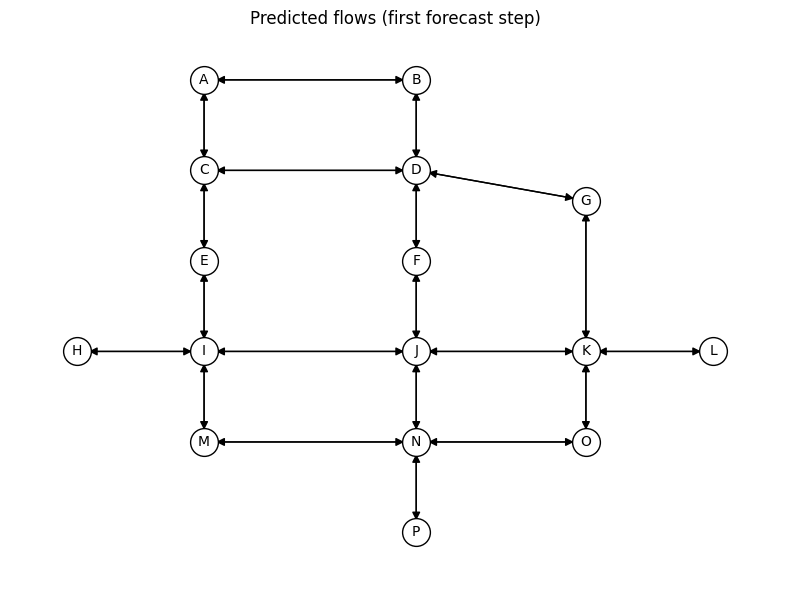

Test: {'MAE': 0.7171243905661406, 'RMSE': 2.2226323614355974}
('A', 'B') 2.646919395136085e-22
('B', 'A') 2.6469297449911615e-22
('A', 'C') 2.646909550151988e-22
('C', 'A') 2.646919395136085e-22
('C', 'E') 2.646919395136085e-22
('E', 'C') 2.6469398424107483e-22
('B', 'D') 2.6469398424107483e-22
('D', 'B') 2.6469398424107483e-22
('D', 'F') 2.646919395136085e-22
('F', 'D') 2.646909550151988e-22


In [12]:
# Ensure inline plotting in notebooks
%matplotlib inline

# 1) Fill in your mapping and coordinates BEFORE running this cell:
#    - SENSOR_TO_EDGE  (base directions)
#    - POS             (exact coordinates)

csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv",
]
weather_csv = None  # or a path like "/content/data/weather_5min_2025.csv"

cfg = Config(
    time_granularity="15min",
    H_in=12*8,          # past hour if 5-min bins
    H_out=12,         # next hour
    batch_size=64,
    lr=1e-4,
    max_epochs=80,
    patience=15,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    use_exog=True
)

artifacts = run_experiment_in_notebook(
    csv_paths=csv_paths,
    weather_csv=weather_csv,
    cfg=cfg,
    partial_policy="dedupe",   # or "sum" if your device sends partials within a bin
    print_every=True
)

# Access results:
print("Test:", artifacts["metrics_test"])
# Example: inspect one predicted vector for the first sample & first horizon
E = len(DIRECTED_EDGES)
first_pred = artifacts["yhat_example"][0,0,:].reshape(E)
for i, val in enumerate(first_pred[:10]):  # show first 10 edges
    print(INDEX_EDGE[i], float(val))


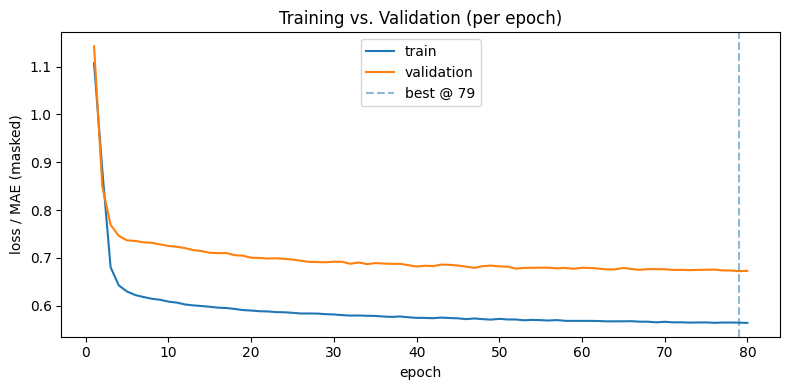

[1.1070069513230953, 0.8826719297553008, 0.6802532855632171, 0.6420473909040667, 0.629378430404753, 0.6220324683301853, 0.617945005308907, 0.6143074755398732, 0.6122614089048134, 0.6083471052489191, 0.6063573970547262, 0.6024554914460992, 0.6004877734296726, 0.5991420650257254, 0.5976183465066945, 0.5957773921062361, 0.5950340665173981, 0.5930489847120249, 0.5907467100417839, 0.589737576414954, 0.588275708398729, 0.5879097420651958, 0.5864075534748581, 0.586101881456825, 0.5850024122112202, 0.5835392826570655, 0.5835545642196007, 0.5833246109058272, 0.5821927934885025, 0.5815245506336104, 0.5801120926186724, 0.5791674894544313, 0.5793826580047607, 0.5787660628557205, 0.5784934334597498, 0.5771699980744776, 0.5764429141890328, 0.5773072147144461, 0.5756557673778174, 0.5743892454313781, 0.5743077675688941, 0.5737000959661772, 0.5750261289331148, 0.5740580353534447, 0.5734696171756061, 0.5717515338141963, 0.5731458110067079, 0.5716976357518502, 0.5707273837530388, 0.572338398053961, 0.571

In [13]:
import numpy as np
import matplotlib.pyplot as plt

h = getattr(artifacts["model"], "history", None)
if not h:
    raise RuntimeError("No history found. Re-run training after replacing train_model.")

epochs = np.array(h["epoch"])
train  = np.array(h["train"])
val    = np.array(h["val"])
best_ix = int(np.argmin(val))

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label="train")
plt.plot(epochs, val,   label="validation")
plt.axvline(epochs[best_ix], linestyle="--", alpha=0.5, label=f"best @ {epochs[best_ix]}")
plt.title("Training vs. Validation (per epoch)")
plt.xlabel("epoch")
plt.ylabel("loss / MAE (masked)")
plt.legend()
plt.tight_layout()
plt.show()

print(h["train"])

In [14]:
# === Cell: collect & show ALL predicted values (TEST split) ===
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# pull from your earlier 'artifacts' dict
model = artifacts["model"]
cfg = artifacts["cfg"]
times = artifacts["times"]
test_ds = artifacts["loaders"]["test"].dataset

# reconstruct where TEST starts in the global timeline (60/20/20 split)
n = len(times)
n_train = int(0.6 * n)
n_val   = int(0.2 * n)
test_start = n_train + n_val

H_in, H_out = cfg.H_in, cfg.H_out
E = len(DIRECTED_EDGES)

# make an eval loader that does NOT drop the final, partial batch
eval_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=cfg.device.startswith("cuda")
)

preds, trues, masks = [], [], []

model.eval()
with torch.no_grad():
    for batch in eval_loader:
        x = batch["x"].to(cfg.device, non_blocking=True)
        y = batch["y"].to(cfg.device, non_blocking=True)
        m = batch["mask"].to(cfg.device, non_blocking=True)
        yhat = model(x)                              # [B, H_out, E]
        preds.append(yhat.cpu().numpy())
        trues.append(y.cpu().numpy())
        masks.append(m.cpu().numpy())

YH = np.concatenate(preds, axis=0)  # [N_eff, H_out, E]
Y  = np.concatenate(trues, axis=0)  # [N_eff, H_out, E]
M  = np.concatenate(masks, axis=0)  # [N_eff, H_out, E]
N_eff = YH.shape[0]

# build a tidy table with timestamp, horizon, edge (u->v), pred/true/observed
records = []
for i in range(N_eff):
    t_start = test_start + H_in + i             # absolute index where this forecast window starts
    for h in range(H_out):
        t_abs = t_start + h
        ts = times[t_abs]
        for e_idx, (u, v) in enumerate(DIRECTED_EDGES):
            records.append({
                "timestamp": ts,
                "h": h,                         # 0 = first step ahead
                "u": u,
                "v": v,
                "edge": f"{u}->{v}",
                "pred": float(YH[i, h, e_idx]),
                "true": float(Y[i, h, e_idx]),
                "observed": bool(M[i, h, e_idx] > 0.5),
            })

df_pred = (pd.DataFrame.from_records(records)
          .sort_values(["timestamp", "h", "u", "v"])
          .reset_index(drop=True))

# show the full table (can be large)
df_pred


,timestamp,h,u,v,edge,pred,true,observed
0,2025-04-08 03:00:00,0,A,B,A->B,2.646919e-22,0.0,False
1,2025-04-08 03:00:00,0,A,C,A->C,2.646910e-22,0.0,True
2,2025-04-08 03:00:00,0,B,A,B->A,2.646930e-22,0.0,False
3,2025-04-08 03:00:00,0,B,D,B->D,2.646940e-22,0.0,True
4,2025-04-08 03:00:00,0,C,A,C->A,2.646919e-22,0.0,True
...,...,...,...,...,...,...,...,...
1055035,2025-05-01 03:00:00,11,N,O,N->O,0.000000e+00,0.0,False
1055036,2025-05-01 03:00:00,11,N,P,N->P,0.000000e+00,0.0,True
1055037,2025-05-01 03:00:00,11,O,K,O->K,0.000000e+00,0.0,True
1055038,2025-05-01 03:00:00,11,O,N,O->N,0.000000e+00,0.0,False


In [15]:
tol = 1e-6
mask = ~np.isclose(df_pred['true'], 0.0, atol=tol)
nz = df_pred.loc[mask].sort_values(['timestamp','h','u','v'])
display(nz)


,timestamp,h,u,v,edge,pred,true,observed
1123,2025-04-08 04:45:00,0,B,D,B->D,2.086844e-08,1.0,True
1127,2025-04-08 04:45:00,0,D,B,D->B,2.086847e-08,1.0,True
1132,2025-04-08 04:45:00,0,E,I,E->I,2.086844e-08,1.0,True
1138,2025-04-08 04:45:00,0,I,E,I->E,2.086847e-08,1.0,True
1163,2025-04-08 04:45:00,1,B,D,B->D,3.772565e-11,1.0,True
...,...,...,...,...,...,...,...,...
1044541,2025-04-30 20:15:00,7,I,M,I->M,1.244044e-32,1.0,True
1044581,2025-04-30 20:15:00,8,I,M,I->M,1.918308e-30,1.0,True
1044621,2025-04-30 20:15:00,9,I,M,I->M,1.494063e-33,1.0,True
1044661,2025-04-30 20:15:00,10,I,M,I->M,1.524369e-31,1.0,True


In [16]:
top = (nz.sort_values('true', ascending=False)
         .loc[:, ['timestamp','h','edge','true','pred','observed']]
         .head(20))
print(top.to_string(index=False))


          timestamp  h edge  true         pred  observed
2025-04-16 11:00:00  7 F->J  73.0 4.957603e+00      True
2025-04-16 11:00:00  8 F->J  73.0 5.871811e+00      True
2025-04-16 11:00:00  3 F->J  73.0 4.687557e+00      True
2025-04-16 11:00:00  9 F->J  73.0 6.980821e+00      True
2025-04-16 11:00:00 11 F->J  73.0 6.726147e+00      True
2025-04-16 11:00:00  1 F->J  73.0 5.505057e+00      True
2025-04-16 11:00:00 10 F->J  73.0 5.886746e+00      True
2025-04-16 11:00:00  4 F->J  73.0 3.943365e+00      True
2025-04-16 11:00:00  0 F->J  73.0 6.146173e+00      True
2025-04-16 11:00:00  6 F->J  73.0 4.463014e+00      True
2025-04-16 11:00:00  5 F->J  73.0 4.249832e+00      True
2025-04-16 11:00:00  2 F->J  73.0 4.362082e+00      True
2025-04-22 06:30:00  8 B->D  63.0 7.269352e-08      True
2025-04-22 06:30:00 10 B->D  63.0 1.650376e-15      True
2025-04-16 06:30:00 11 B->D  63.0 2.026642e-20      True
2025-04-16 06:30:00 10 B->D  63.0 2.351603e-18      True
2025-04-22 06:30:00  3 B->D  63

In [17]:
per_edge = (df_pred.groupby('edge')['true']
              .agg(max_true='max', mean_true='mean', count='size')
              .sort_values('mean_true', ascending=False))
per_edge.head(10)


,max_true,mean_true,count
edge,,,
B->D,63.0,4.070140,26376
D->B,44.0,3.617721,26376
J->F,33.0,2.401274,26376
F->J,73.0,2.013194,26376
C->A,16.0,1.284349,26376
K->O,40.0,0.847551,26376
N->P,26.0,0.824765,26376
O->K,36.0,0.788899,26376
P->N,15.0,0.777942,26376


In [18]:
# === Pre-flight checks (run before the training cell) ===
from pathlib import Path
import pandas as pd
import numpy as np

# 0) File exists?
for p in [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv"
]:
    if not Path(p).exists():
        raise FileNotFoundError(f"CSV not found: {p}")
print("✓ CSV found")

# 1) Peek at the CSV schema quickly
peek = pd.read_csv(
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    nrows=5
)
print("Columns:", list(peek.columns))

required_cols = {"sensor_id","element_name","start_time","count_in","count_out"}
missing = required_cols - set(peek.columns)
if missing:
    raise ValueError(f"CSV missing required columns: {missing}")
print("✓ Required columns present")

# 2) Mapping coverage sanity check (quick sample of keys)
raw_sample = pd.read_csv(
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    usecols=["sensor_id","element_name"], nrows=5000
)
raw_sample["sensor_key"] = raw_sample["sensor_id"].astype(str) + "|" + raw_sample["element_name"].astype(str)
all_keys = set(raw_sample["sensor_key"].unique())
mapped_keys = set(SENSOR_TO_EDGE.keys())

unmapped = sorted(all_keys - mapped_keys)
print(f"Mapped keys in dict: {len(mapped_keys)} | Keys seen in sample: {len(all_keys)}")
if unmapped:
    print("⚠ Unmapped sensor keys (first 20):", unmapped[:20])
    # Not fatal, but you’ll get zeros on those edges; add them to SENSOR_TO_EDGE when possible.
else:
    print("✓ All sampled keys are mapped")

# 3) Coordinates present?
if not POS:
    raise ValueError("POS (node coordinates) is empty. Fill POS before training.")
unknown_nodes = [n for n in NODES if n not in POS]
if unknown_nodes:
    raise ValueError(f"Missing coordinates for nodes: {unknown_nodes}")
print("✓ Coordinates loaded for all nodes")

# 4) Presence-based mask function in use?
try:
    build_edge_time_matrix  # function must exist
    print("✓ build_edge_time_matrix is defined")
except NameError:
    raise RuntimeError("build_edge_time_matrix is not defined in this notebook session.")

print("Pre-flight checks passed.")


✓ CSV found
Columns: ['pkey_id', 'created_at', 'sensor_id', 'start_time', 'end_time', 'count_in', 'count_out', 'element_id', 'element_name']
✓ Required columns present
Mapped keys in dict: 13 | Keys seen in sample: 32
⚠ Unmapped sensor keys (first 20): ['TUD_SBX07-MULTI|Line 4', 'TUD_SBX07-MULTI|Line 5', 'TUD_SBX07A|Line  1', 'TUD_SBX07A|Line 2', 'TUD_SBX07A|Line 3', 'TUD_SBX07|Line 0', 'TUD_SBX07|Line 2', 'TUD_SBX07|Line 3', 'TUD_SBX26|Line 2', 'TUD_SBX27|Line 0', 'TUD_SBXN8A|Line 0', 'TUD_SBXN8B|Line 0', 'TUD_SBXN9A|Line 0', 'TUD_SBXN9B|Line 0', 'TUD_SBXS12|Line 0', 'TUD_SBXS13|Line 0', 'TUD_SPX14|Line 0', 'TUD_SPX15|Line 0', 'TUD_SPXS06_IO|Line 0']
✓ Coordinates loaded for all nodes
✓ build_edge_time_matrix is defined
Pre-flight checks passed.


B->D — 2025-04-24  MAE=2.097, RMSE=5.070  (on observed bins)


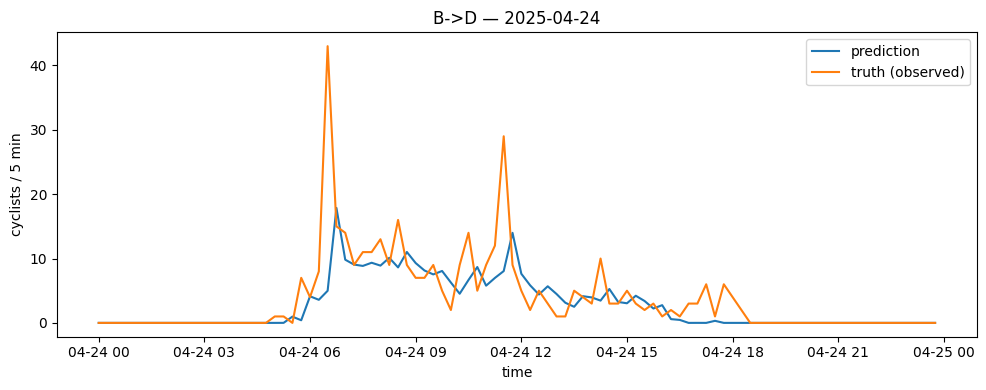

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# # pick the edge and the calendar day you want to visualise
# edge_uv = ('B','D')            # <-- change me
# day_str = '2025-01-30'         # <-- change me (YYYY-MM-DD)

# edge_str = f"{edge_uv[0]}->{edge_uv[1]}"
# day = pd.to_datetime(day_str).date()

# # filter to that edge & day
# sel = df_pred[(df_pred['edge'] == edge_str) &
#               (df_pred['timestamp'].dt.date == day)].copy()

# # keep only bins with ground truth (observed)
# sel_true = sel[sel['observed']].copy()

# # sort & drop duplicates (shouldn’t exist, but safe)
# sel = sel.sort_values(['timestamp','h'])
# sel_true = sel_true.sort_values(['timestamp','h'])

# # build time series (one point per timestamp)
# ts_pred = sel.groupby('timestamp', as_index=True)['pred'].mean()
# ts_true = sel_true.groupby('timestamp', as_index=True)['true'].mean()

edge_uv = ('B','D')           # <-- change me
day_str = '2025-04-24'        # <-- change me (YYYY-MM-DD)

edge_str = f'{edge_uv[0]}->{edge_uv[1]}'
sel = df_pred[(df_pred['edge']==edge_str) &
              (df_pred['timestamp'].dt.date==pd.to_datetime(day_str).date())]

# keep the *smallest* horizon per timestamp
sel = (sel.sort_values(['timestamp','h'])
           .drop_duplicates(['timestamp','edge'], keep='first'))

ts_pred = sel.set_index('timestamp')['pred']
ts_true = sel[sel['observed']].set_index('timestamp')['true']


# compute metrics on common timestamps with truth
common_idx = ts_true.index.intersection(ts_pred.index)
mae = float(np.mean(np.abs(ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))))
rmse = float(np.sqrt(np.mean((ts_pred.reindex(common_idx) - ts_true.reindex(common_idx))**2)))
print(f"{edge_str} — {day_str}  MAE={mae:.3f}, RMSE={rmse:.3f}  (on observed bins)")

# plot
plt.figure(figsize=(10,4))
plt.plot(ts_pred.index, ts_pred.values, label='prediction')
plt.plot(ts_true.index, ts_true.values, label='truth (observed)')
plt.title(f"{edge_str} — {day_str}")
plt.xlabel("time")
plt.ylabel("cyclists / 5 min")
plt.legend()
plt.tight_layout()
plt.show()
